<a href="https://colab.research.google.com/github/rainforest01-coder/ESAA_files/blob/main/week3%EC%88%98%EC%83%81%EC%9E%91_%EC%88%98%EB%A3%8C%EC%98%88%EC%B8%A12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

악성 URL 분류 AI 경진대회

https://www.dacon.io/competitions/official/236451/codeshare/12286

-데이터 특징
> 약 7백만개의 url데이터와 레이

1. 코드흐름 요약
* 전처리
> urlparse 라이브러리 사용해여 url을 각 구성요소로 구분
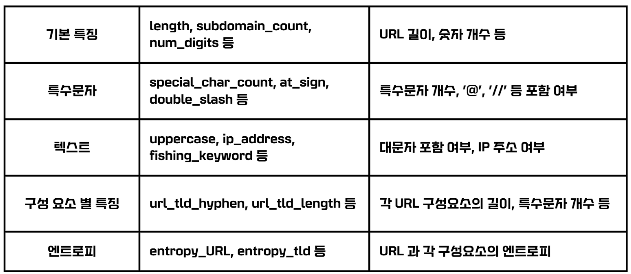

* Modeling
트리 기반 모델 xgb,catboost,lgbm사용
피처 기반 정형 데이터는 트리기반 머신러닝 모델이 적합하다고 생각, 데이터 샘플이 매우 많아 딥러닝을 사용하기에는 컴퓨팅 자원 부족,
로지스틱 회귀, 랜덤포레스트 등 모델은 GPU자원을 사용하지 못해 모델 학습에 너무 많은 시간 소요

옵튜나 이용해 하이퍼 파라미터 튜닝



2. 새롭게 알게된 점

-데이터가 많을 경우 전산자원을 고려하여 모델을 선택해야 한다는 사실을 알았고, 딥러닝, 로지스틱 회귀, 랜덤포레스트 등은 컴퓨팅 자원으로 인해 많은 시간이 소요된다는 사실도 알았다
-urlsparse를 사용하면 url을 구성요소로 분해할 수 있다는 것을 알았다.
-이외에도 매우 많은 특성들을 뽑아냄

In [ ]:
def parse_url_components(url):
    try:
        # URL 앞부분에 http:// 추가
        if not url.startswith('http://') and not url.startswith('https://'):
            url = 'http://' + url

        parsed = urlparse(url)
        domain = parsed.netloc
        domain_parts = domain.split('.')

        components = {
            'domain': domain,
            'path': parsed.path if parsed.path else '',
            'params': parsed.params if parsed.params else '',
            'query': parsed.query if parsed.query else '',
            'fragment': parsed.fragment if parsed.fragment else '',
            'tld': domain_parts[-1] if domain_parts else '',
            'sld': domain_parts[-2] if len(domain_parts) > 1 else '',
            'subdomain': '.'.join(domain_parts[:-2]) if len(domain_parts) > 2 else ''
        }

        return components